**环境说明：** 请在运行下方 Spark 初始化代码前 **重启内核**（若曾报错），以便 `SPARK_HOME` 在首次加载 PySpark 前生效。诊断版本可在终端执行：`python3 -c "import pyspark; print(pyspark.__version__)"`。

In [2]:
import os
import sys
import importlib.util
import subprocess

# 在导入 pyspark 之前对齐 SPARK_HOME，避免 JVM 与 pip 中 pyspark 版本不一致
# （否则会报 org.apache.spark.sql.classic.SparkSession$ does not exist in the JVM）
_spec = importlib.util.find_spec("pyspark")
if _spec is None or not _spec.origin:
    raise RuntimeError("未找到 pyspark，请先安装：pip install pyspark")
os.environ["SPARK_HOME"] = os.path.dirname(_spec.origin)

try:
    _java_home = subprocess.check_output(
        "readlink -f $(which java) | sed 's|/bin/java||'",
        shell=True,
        text=True,
    ).strip()
    os.environ["JAVA_HOME"] = _java_home
except Exception:
    os.environ.setdefault("JAVA_HOME", "/usr/lib/jvm/java-17-openjdk")

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

# 若内核中已有旧的 SparkContext，先停止再创建会话
try:
    from pyspark import SparkContext

    _sc = SparkContext._active_spark_context
    if _sc is not None:
        _sc.stop()
except Exception:
    pass

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder.appName("MyProject")
    .config("spark.local.dir", "/root/spark_temp")
    .config("spark.driver.memory", "4g")
    .config("spark.executor.memory", "4g")
    .config("spark.sql.debug.maxToStringFields", "2000")
    .getOrCreate()
)
spark.conf.set("spark.sql.debug.maxToStringFields", 2000)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/27 00:07:07 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/27 00:07:08 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in standalone/kubernetes and LOCAL_DIRS in YARN).
26/04/27 00:07:08 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [3]:
import pandas as pd
from pyspark.sql import functions as F
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [2]:
df = spark.read.csv("/root/elm_eval.csv", header=False)
df.limit(5).show()

+---+--------------------+---+---+------------------+---+---+---+-------+--------------------+--------------------+----+----+----------+------+------------+------+----+-----+----+----+----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------+----+---------+----+------------+
|_c0|                 _c1|_c2|_c3|               _c4|_c5|_c6|_c7|    _c8|                 _c9|                _c10|_c11|_c12|      _c13|  _c14|        _c15|  _c16|_c17| _c18|_c19|_c20|_c21|                _c22|                _c23|                _c24|                _c25|                _c26|                _c27|                _c28|                _c29|                _c30|                _c31|                _c32|                _c33|      _c34|_c35|     _c36|_c37|        _c38|
+---+--------------------+--

In [3]:
new_column_names = [ 
    "_c0",                                # _c0
    "user_id_masked",                     # 用户脱敏ID
    "user_gender",                        # 用户性别
    "user_visit_city_id",                 # 用户访问的城市ID
    "user_avg_price_hist",                # 用户历史平均单价
    "is_vip",                             # 用户是否开通VIP
    "user_click_rate_30d",                # 用户30天内的点击率
    "user_order_cnt_30d",                 # 用户三十天内的下单量
    "user_trade_amt_30d",                 # 用户30天内的交易金额
    "shop_id_masked",                     # 店铺脱敏ID
    "item_id_masked",                     # 商品脱敏ID
    "item_city_id",                       # 商品所处的城市ID
    "item_district_id",                   # 商品所处的区域ID
    "item_aoi_id",                        # 商品所处的aoi_ID
    "item_geohash6",                      # 商品所处的geohash6
    "item_geohash12",                     # 商品所处的geohash12
    "brand_id",                           # 品牌id
    "item_cat1_id",                       # 商品一级类目id
    "item_std_dish_cat_id",               # 商品标准菜类目id
    "item_sales_rank_7d",                 # 商品近7天在店内的畅销度排名
    "item_sales_rank_30d",                # 商品近30天在店内的畅销度排名
    "item_sales_rank_90d",                # 商品近90天在店内的畅销度排名
    "click_hist_shop_id_masked",                # 被点击的历史店铺脱敏id
    "click_hist_item_id_masked",                # 被点击的历史商品脱敏id
    "click_hist_item_cat1_id",                  # 被点击的历史商品一级类目id
    "click_hist_item_std_dish_id",              # 被点击的历史商品标准菜品id
    "click_hist_brand_id",                      # 被点击的历史商品品牌id
    "click_hist_item_price",                    # 被点击的历史商品的价格
    "click_hist_item_aoi_id",                   # 被点击的历史商品的aoi id
    "click_hist_item_geohash6",                 # 被点击的历史商品所处的geohash6
    "click_hist_time_diff_s",                   # 被点击的历史时间与当前时间的时间差(单位为s)
    "click_hist_click_hour",                    # 被点击的历史时间(h)
    "click_hist_click_time_slot",               # 被点击历史时间时间段
    "click_hist_click_day_of_week",             # 被点击历史时间星期几
    "request_timestamp",                  # 用户请求时间
    "current_hour",                       # 用户当前时间(hour)
    "current_time_slot",                  # 用户当前时间段
    "current_day_of_week",                # 用户当前星期几
    "user_geohash12"                      # 用户所处位置geohash12
]

In [4]:
print(f"当前列表长度: {len(new_column_names)}")
print(f"表格实际列数: {len(df.columns)}")

当前列表长度: 39
表格实际列数: 39


In [5]:
df = df.toDF(*new_column_names)
df.limit(5).show()

+---+--------------------+-----------+------------------+-------------------+------+-------------------+------------------+------------------+--------------------+--------------------+------------+----------------+-----------+-------------+--------------+--------+------------+--------------------+------------------+-------------------+-------------------+-------------------------+-------------------------+-----------------------+---------------------------+--------------------+---------------------+----------------------+------------------------+----------------------+---------------------+--------------------------+----------------------------+-----------------+------------+-----------------+-------------------+--------------+
|_c0|      user_id_masked|user_gender|user_visit_city_id|user_avg_price_hist|is_vip|user_click_rate_30d|user_order_cnt_30d|user_trade_amt_30d|      shop_id_masked|      item_id_masked|item_city_id|item_district_id|item_aoi_id|item_geohash6|item_geohash12|brand_i

In [ ]:
## 新增，用于查看request_timestamp是否为10位数字
df.select("request_timestamp").where(~F.col("request_timestamp").rlike("^[0-9]{10}$")).show(50, False)
## 可以看到这里是正常的。

+-----------------+
|request_timestamp|
+-----------------+
+-----------------+



In [32]:
## 删除重复值   
df=df.drop_duplicates()
## 这里做了改动，不做精确度转化
df = df.withColumn("user_avg_price_hist", F.col("user_avg_price_hist").cast("float"))
df = df.withColumn("user_trade_amt_30d", F.col("user_trade_amt_30d").cast("float"))
## 这里做了改动,C0代表正负样本，click_hist_time_diff_s代表活跃度，不作删除
new_head=df.limit(10).toPandas()

In [33]:
new_head.head(10)

,_c0,user_id_masked,user_gender,user_visit_city_id,user_avg_price_hist,is_vip,user_click_rate_30d,user_order_cnt_30d,user_trade_amt_30d,shop_id_masked,item_id_masked,item_city_id,item_district_id,item_aoi_id,item_geohash6,item_geohash12,brand_id,item_cat1_id,item_std_dish_cat_id,item_sales_rank_7d,item_sales_rank_30d,item_sales_rank_90d,click_hist_shop_id_masked,click_hist_item_id_masked,click_hist_item_cat1_id,click_hist_item_std_dish_id,click_hist_brand_id,click_hist_item_price,click_hist_item_aoi_id,click_hist_item_geohash6,click_hist_time_diff_s,click_hist_click_hour,click_hist_click_time_slot,click_hist_click_day_of_week,request_timestamp,current_hour,current_time_slot,current_day_of_week,user_geohash12
0,0,601b640aa477c38bcdcfabc4108a6c3264123e2774cadf1266a0085076bca789,2,14,90.387779,1,139,45,4067.449951,a351d550ead292285c2b62b056ad68472fa3bcd4c0f0e1e7b9d4a8d623aefc21,4f29469f9ea86086d01eab3594650665c98f91d6fedf8a18dc858e450d5ad1dd,14,5746,B0FFG7LQ2U,wm6n3d,wm6n3dypbkqk,0,1066,22614,1,1,1,69b2f6a7b7b88a57ee5864995590afab7eeaf5ffd7ded0f5772a05ef2dc0a3c7;69b2f6a7b7b88a57ee5864995590afab7eeaf5ffd7ded0f5772a05ef2dc0a3c7;69b2f6a7b7b88a57ee5864995590afab7eeaf5ffd7ded0f5772a05ef2dc0a3c7;69b2f6a7b7b88a57ee5864995590afab7eeaf5ffd7ded0f5772a05ef2dc0a3c7;69b2f6a7b7b88a57ee5864995590afab7eeaf5ffd7ded0f5772a05ef2dc0a3c7;69b2f6a7b7b88a57ee5864995590afab7eeaf5ffd7ded0f5772a05ef2dc0a3c7;69b2f6a7b7b88a57ee5864995590afab7eeaf5ffd7ded0f5772a05ef2dc0a3c7;69b2f6a7b7b88a57ee5864995590afab7eeaf5ffd7ded0f5772a05ef2dc0a3c7;2509622a17c9bb563de5683afb9f905f06da60fdb043dcf65ff6926d07668037;2509622a17c9bb563de5683afb9f905f06da60fdb043dcf65ff6926d07668037;02e00be0a5710683d42ffedb29b2cc9884120aa69833133d41e1306fc6035088;146e47dfe5fc5d70017e404e2f8f31c5fb603d73ee7cd4a26c056b9b506f4f46;311a0c5f6887ccea35b1812580fee63526a978328f5ee87aa327d634cbf241f5;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300bd7c14;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300bd7c14;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300bd7c14;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300bd7c14;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300bd7c14;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300bd7c14;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300bd7c14;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300bd7c14;ca26884e5177b47452b46cc32f4d7e1677560a41025351b5e286ea615d8ed196;ca26884e5177b47452b46cc32f4d7e1677560a41025351b5e286ea615d8ed196;ca26884e5177b47452b46cc32f4d7e1677560a41025351b5e286ea615d8ed196;ca26884e5177b47452b46cc32f4d7e1677560a41025351b5e286ea615d8ed196;06dd9d5f8c72f4d74d7331effb646820ddea20d389c690b983a080417c04e0f7;06dd9d5f8c72f4d74d7331effb646820ddea20d389c690b983a080417c04e0f7;06dd9d5f8c72f4d74d7331effb646820ddea20d389c690b983a080417c04e0f7;4fd1ad2a3a431a5d986659e3e56becb7d67a7a50b6352e5c2e9eb370b36158b4;4fd1ad2a3a431a5d986659e3e56becb7d67a7a50b6352e5c2e9eb370b36158b4;4fd1ad2a3a431a5d986659e3e56becb7d67a7a50b6352e5c2e9eb370b36158b4;4fd1ad2a3a431a5d986659e3e56becb7d67a7a50b6352e5c2e9eb370b36158b4;4fd1ad2a3a431a5d986659e3e56becb7d67a7a50b6352e5c2e9eb370b36158b4;4fd1ad2a3a431a5d986659e3e56becb7d67a7a50b6352e5c2e9eb370b36158b4;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300bd7c14

In [9]:
## 统计用户性别不用执行
from pyspark.sql import functions as F
vip_col = "user_gender"

df.groupBy(vip_col).count().orderBy(vip_col).show()

+-----------+------+
|user_gender| count|
+-----------+------+
|       NULL| 27468|
|        -99| 43741|
|          1|166136|
|          2|256205|
+-----------+------+



In [38]:
## 查看-99值，不用执行
from pyspark.sql import functions as F
exclude_cols = [    
    'click_hist_shop_id_masked',   
    'click_hist_item_id_masked',   
    'click_hist_time_diff_s',     
    'click_hist_item_cat1_id',       # 被点击的历史商品一级类目id
    'click_hist_item_std_dish_id',   # 被点击的历史商品标准菜品id
    'click_hist_brand_id',           # 被点击的历史商品品牌id
    'click_hist_item_price',         # 被点击的历史商品的价格
    'click_hist_item_aoi_id',        # 被点击的历史商品的aoi id
    'click_hist_item_geohash6',      # 被点击的历史商品所处的geohash6
    'click_hist_click_hour', 
    'click_hist_click_time_slot',     # 被点击的历史时间段（早餐晚餐中餐）
    'click_hist_click_day_of_week'   # 被点击历史时间星期几
]

# 2. 获取剩下的需要统计的列
cols_to_check = [c for c in df.columns if c not in exclude_cols]

# 3. 构造统计指令
stats = []
for c in cols_to_check:
    stats.append(F.count(F.when(F.col(c).cast("string") == "-99", c)).alias(f"{c}_99"))

print(f"正在统计 {len(cols_to_check)} 列的异常值（-99）...")
missing_df = df.select(stats)
missing_df2=missing_df.toPandas().T
missing_df2
##统计null和-1值

正在统计 27 列的异常值（-99）...


,0
_c0_99,0
user_id_masked_99,0
user_gender_99,43741
user_visit_city_id_99,0
user_avg_price_hist_99,0
is_vip_99,0
user_click_rate_30d_99,0
user_order_cnt_30d_99,0
user_trade_amt_30d_99,0
shop_id_masked_99,0


In [46]:
##统计null和-1值
exclude_cols = [   
    '_c0',
    'click_hist_shop_id_masked',   
    'click_hist_item_id_masked',   
    'click_hist_time_diff_s',         
    'click_hist_item_cat1_id',       # 被点击的历史商品一级类目id
    'click_hist_item_std_dish_id',   # 被点击的历史商品标准菜品id
    'click_hist_brand_id',           # 被点击的历史商品品牌id
    'click_hist_item_price',         # 被点击的历史商品的价格
    'click_hist_item_aoi_id',        # 被点击的历史商品的aoi id
    'click_hist_item_geohash6',      # 被点击的历史商品所处的geohash6
    'click_hist_click_hour', 
    'click_hist_click_time_slot',     # 被点击的历史时间段（早餐晚餐中餐）
    'click_hist_click_day_of_week'   # 被点击历史时间星期几
]

# 2. 获取剩下的需要统计的列
cols_to_check = [c for c in df.columns if c not in exclude_cols]

# 3. 构造统计指令
stats = []
for c in cols_to_check:
    # 统计 Null 值
    stats.append(F.count(F.when(F.col(c).isNull(), c)).alias(f"{c}_Null"))
    # 统计 -1 (转为字符串比较以防报错)
    stats.append(F.count(F.when(F.col(c).cast("string") == "-1", c)).alias(f"{c}_-1"))
    #这里去掉了0
    
# 4. 执行统计并逐列打印（避免 show(vertical=True) 因 maxToStringFields 省略 ...）
print(f"正在统计 {len(cols_to_check)} 列的异常值（Null,-1）...")
missing_df = df.select(stats)
_row = missing_df.collect()[0]
_w = max(len(c) for c in missing_df.columns)
for _c in missing_df.columns:
    print(f"{_c:{_w}s} | {_row[_c]}")

正在统计 26 列的异常值（Null,-1）...


user_id_masked_Null       | 0
user_id_masked_-1         | 0
user_gender_Null          | 71209
user_gender_-1            | 0
user_visit_city_id_Null   | 42692
user_visit_city_id_-1     | 0
user_avg_price_hist_Null  | 27468
user_avg_price_hist_-1    | 0
is_vip_Null               | 27468
is_vip_-1                 | 0
user_click_rate_30d_Null  | 27468
user_click_rate_30d_-1    | 0
user_order_cnt_30d_Null   | 27468
user_order_cnt_30d_-1     | 0
user_trade_amt_30d_Null   | 27468
user_trade_amt_30d_-1     | 0
shop_id_masked_Null       | 0
shop_id_masked_-1         | 0
item_id_masked_Null       | 0
item_id_masked_-1         | 0
item_city_id_Null         | 6587
item_city_id_-1           | 0
item_district_id_Null     | 8842
item_district_id_-1       | 0
item_aoi_id_Null          | 121034
item_aoi_id_-1            | 0
item_geohash6_Null        | 121034
item_geohash6_-1          | 0
item_geohash12_Null       | 121034
item_geohash12_-1         | 0
brand_id_Null             | 293183
brand_id_-1     

In [37]:
## 仅用于统计0值，可不执行
stats2 = []
for c in cols_to_check:
    # 统计 0 值
    stats2.append(F.count(F.when(F.col(c).cast("string") == "0", c)).alias(c))

missing_df2 = df.select(stats2)

pdf_result = missing_df2.toPandas().T

pdf_result.columns = ['Count_Zero']

pdf_result

,Count_Zero
_c0,399978
user_id_masked,0
user_gender,0
user_visit_city_id,0
user_avg_price_hist,0
is_vip,195595
user_click_rate_30d,15330
user_order_cnt_30d,37468
user_trade_amt_30d,0
shop_id_masked,0


In [47]:
col2_substitude=[
    'brand_id',
    'item_std_dish_cat_id',
    'item_cat1_id'
]
cols_to_check2_0 = [c for c in col2_substitude if c in df.columns]
update_exprs = [
    (
        F.when(
            (F.col(c).cast("string") == "-1") & F.lit(c in cols_to_check)
            | (F.col(c).cast("string") == "0") & F.lit(c in cols_to_check2_0)
            | (F.col(c)==-99) & F.lit(c in 'user_gender'),
            F.lit(None),
        ).otherwise(F.col(c)).alias(c)
    )
    for c in df.columns
]

# 2. 执行替换（产生新的 df）
df = df.select(*update_exprs)



## 这里所有缺失值都替换为null 

In [42]:
null_stats = [F.sum(F.col(c).isNull().cast("int")).alias(c) for c in cols_to_check]

# 2. 执行统计
print("正在计算全表各列的 Null 值总数...")
null_df = df.select(null_stats)

# 3. 显示结果：逐列打印，避免 Spark 纵向 show 中间出现 ...
_row = null_df.collect()[0].asDict()
_w = max(len(c) for c in null_df.columns)
for _c in null_df.columns:
    print(f"{_c:{_w}s} | {_row[_c]}")

正在计算全表各列的 Null 值总数...


_c0                  | 0
user_id_masked       | 0
user_gender          | 71209
user_visit_city_id   | 42692
user_avg_price_hist  | 27468
is_vip               | 27468
user_click_rate_30d  | 27468
user_order_cnt_30d   | 27468
user_trade_amt_30d   | 27468
shop_id_masked       | 0
item_id_masked       | 0
item_city_id         | 6587
item_district_id     | 8842
item_aoi_id          | 121034
item_geohash6        | 121034
item_geohash12       | 121034
brand_id             | 293183
item_cat1_id         | 194
item_std_dish_cat_id | 244899
item_sales_rank_7d   | 66573
item_sales_rank_30d  | 39656
item_sales_rank_90d  | 35297
request_timestamp    | 0
current_hour         | 0
current_time_slot    | 0
current_day_of_week  | 0
user_geohash12       | 6566


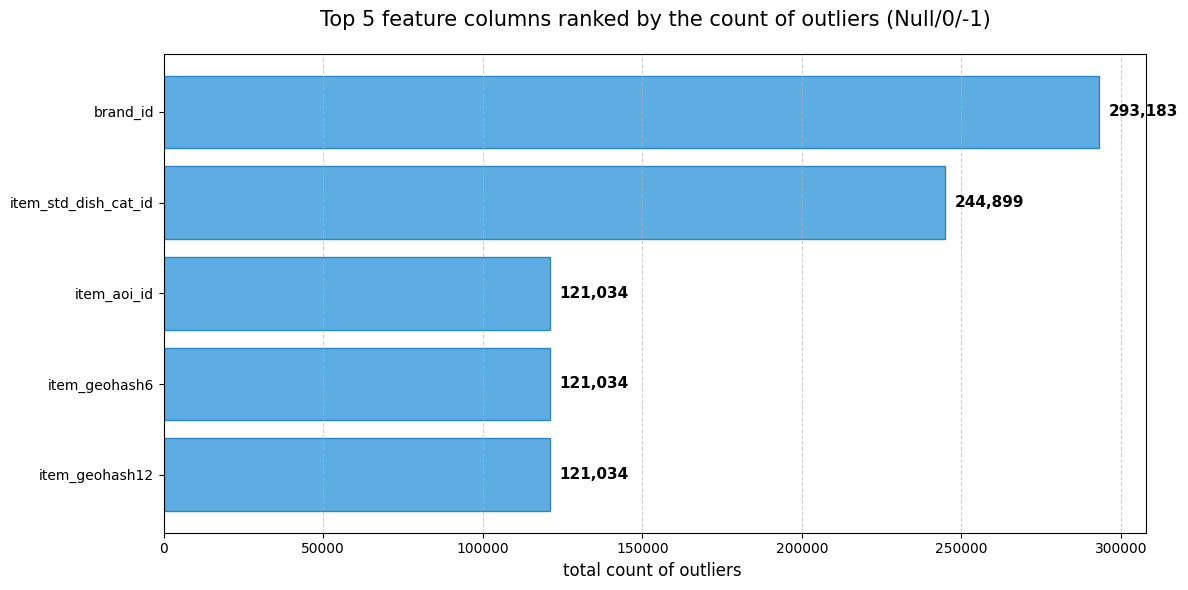

In [48]:
import matplotlib.pyplot as plt

# 1. 将 missing_df 的这一行数据转为 Python 字典
missing_row =null_df.collect()[0].asDict()

# 2. 排序并获取前五名 (按缺失数量从高到低)
# x[1] 代表数量，x[0] 代表列名
top_5_counts = sorted(missing_row.items(), key=lambda x: x[1], reverse=True)[:5]

# 3. 准备绘图数据 (为了让最大的排在上面，我们反转一下列表)
top_5_reversed = top_5_counts[::-1]
labels = [x[0] for x in top_5_reversed]
counts = [x[1] for x in top_5_reversed]

# 4. 绘图
plt.figure(figsize=(12, 6))
bars = plt.barh(labels, counts, color='#5DADE2', edgecolor='#2E86C1')

# 5. 美化图表
plt.title('Top 5 feature columns ranked by the count of outliers (Null/0/-1)', fontsize=15, pad=20)
plt.xlabel('total count of outliers ', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# 在条形末端添加具体的数值
for bar in bars:
    width = bar.get_width()
    plt.text(width + (max(counts) * 0.01), bar.get_y() + bar.get_height()/2, 
             f'{int(width):,}', ha='left', va='center', fontsize=11, fontweight='bold')


plt.tight_layout()
plt.show()

##### 三个特征缺失值一致，说明具有强关联性 
1. 强关联性：它们属于同一个“业务逻辑组”
这说明这三个字段是联动生成的。

逻辑推断：在原始数据录入时，这三个字段可能都依赖于同一个底层的“位置服务（LBS）”或“经纬度坐标”。

结论：如果某个样本（item）没有地理位置信息，那么这三个字段会同时缺失。它们共享同一个数据源头。

2. 字段冗余提示
geohash6 和 geohash12 本质上是经纬度的不同精度的编码（12位比6位更精确）。

信息重合：既然它们的缺失情况完全一样，说明它们提供的是同一维度的信息。在做 CTR 预估特征工程时，你可能不需要全部保留。

建议：通常保留一个精度适中的（如 geohash6 用于区域刻画）或者根据模型表现选一个即可，全放进去可能会增加模型的维度压力（维度灾难）。

3. 数据质量问题的定位
这个一致的数字（121,034）可以帮你反推数据流：

链路故障：可能是由于某些 item 本身就没有配置地理位置属性，或者是数据爬取/上报阶段，位置接口返回了空值。

业务含义：这部分缺失的样本是否集中在某些特定类型的“item”上？比如某些虚拟商品（没有物理位置）可能就会导致这三个地理特征集体缺失。

In [49]:
total_rows = df.count()
missing_data = null_df.collect()[0].asDict()
missing_percentages = {
    col_name: round((count / total_rows) * 100, 2) 
    for col_name, count in missing_data.items() 
    if count > 0
}
print(f"column with outliers and percentage")
sorted_missing = sorted(missing_percentages.items(), key=lambda x: x[1], reverse=True)
for col, percent in sorted_missing:
    print(f"{col:.<35} {percent}%")

column with outliers and percentage
brand_id........................... 59.4%
item_std_dish_cat_id............... 49.62%
item_aoi_id........................ 24.52%
item_geohash6...................... 24.52%
item_geohash12..................... 24.52%
user_gender........................ 14.43%
item_sales_rank_7d................. 13.49%
user_visit_city_id................. 8.65%
item_sales_rank_30d................ 8.03%
item_sales_rank_90d................ 7.15%
user_avg_price_hist................ 5.57%
is_vip............................. 5.57%
user_click_rate_30d................ 5.57%
user_order_cnt_30d................. 5.57%
user_trade_amt_30d................. 5.57%
item_district_id................... 1.79%
item_city_id....................... 1.33%
user_geohash12..................... 1.33%
item_cat1_id....................... 0.04%


## 缺失值 / 异常值（Null、0、-1）处理建议（对应上面缺失占比）

先把“缺失/异常”的取值统一成真正的 `null`，再按列类型填充或保留。

### 1）统一缺失值口径（建议先做）
- **把 `0` / `-1` 当缺失的列**：通常是计数/金额/排名/ID 等被用作占位符时。
- **不应该把 `0` 当缺失的列**：真实允许为 0 的指标（例如“近 30 天下单数=0”、“交易额=0”、“点击率=0”）。

示例（把 `-1` 统一转为 null；是否把 `0` 当缺失按列来定）：

```python
from pyspark.sql import functions as F

def to_null(df, cols, bad_values):
    """把 bad_values 里的值统一替换成 null"""
    for c in cols:
        cond = F.col(c).isNull()
        for v in bad_values:
            cond = cond | (F.col(c).cast('string') == str(v))
        df = df.withColumn(c, F.when(cond, F.lit(None)).otherwise(F.col(c)))
    return df

# 例：仅把 -1 当缺失（更安全）
cols_minus1 = [
    'brand_id','item_std_dish_cat_id','item_aoi_id','item_geohash6','item_geohash12',
    'item_sales_rank_7d','item_sales_rank_30d','item_sales_rank_90d',
    'user_gender','user_visit_city_id','item_cat1_id'
]
df1 = to_null(df, cols_minus1, bad_values=[-1])
```

### 2）按字段类型处理（推荐规则）
- **ID / 类别型（如 `brand_id`, `item_std_dish_cat_id`, `item_aoi_id`, `user_gender`, `user_visit_city_id`, `item_cat1_id`）**  
  - **做法**：用一个统一类别填充，例如 `'unknown'`（并转成 string 方便后续建模/编码）。

- **地理哈希（`item_geohash6`, `item_geohash12`, `user_geohash12`）**  
  - **做法**：缺失用 `'unknown'`；如果你后续会做 geohash 拆分/embedding，统一为字符串更稳。

- **排名类（`item_sales_rank_7d/30d/90d`）**  
  - **做法**：两种常见方案二选一：
    - **方案 A（推荐）**：缺失填一个很大的值（例如 `9999` 或 `max(rank)+1`），表示“没上榜/未知”。
    - **方案 B**：缺失填中位数/均值（不太推荐，会把“没上榜”当成普通排名）。

- **连续数值（如 `user_avg_price_hist`）**  
  - **做法**：用 **中位数** 填充（比均值抗异常值）。

- **计数/金额/比率（如 `user_order_cnt_30d`, `user_trade_amt_30d`, `user_click_rate_30d`）**  
  - **做法**：如果业务上“没有记录=0”成立，就填 **0**；如果 `-1` 是占位符，先转 null 再填 0。

### 3）一个可直接套用的批量填充模板

```python
from pyspark.sql import functions as F

# A. 类别列：缺失 -> 'unknown'
cat_cols = [
    'brand_id','item_std_dish_cat_id','item_aoi_id','item_geohash6','item_geohash12',
    'user_gender','user_visit_city_id','item_cat1_id'
]

df2 = df1
for c in cat_cols:
    df2 = df2.withColumn(
        c,
        F.when(F.col(c).isNull(), F.lit('unknown')).otherwise(F.col(c).cast('string'))
    )

# B. 排名列：缺失 -> 9999
rank_cols = ['item_sales_rank_7d','item_sales_rank_30d','item_sales_rank_90d']
df2 = df2.fillna({c: 9999 for c in rank_cols})

# C. 数值列：中位数/0 填充
median_price = df2.stat.approxQuantile('user_avg_price_hist', [0.5], 0.01)[0]
if median_price is None or median_price <= 0:
    median_price = 20.0

df2 = df2.fillna({
    'user_avg_price_hist': float(median_price),
    'user_order_cnt_30d': 0,
    'user_trade_amt_30d': 0,
    'user_click_rate_30d': 0.0,
})

df_filled = df2
```

### 4）建议你最后再验证一次
- 重新跑你上面统计缺失值占比的代码，确认这些高缺失列是否按预期变成 0%（或显著下降）。
- 如果后续要训练模型，建议再额外加一个 **缺失指示特征**（例如 `brand_id_is_missing`），有时能提升效果。

In [50]:
# 1. 自动找出缺失率在 0% 到 3% 之间的所有列
low_missing_cols = [col for col, per in missing_percentages.items() if 0 < per < 3]
print(f"检测到缺失率低于 3% 的列共有 {len(low_missing_cols)} 个：")
print(low_missing_cols)

检测到缺失率低于 3% 的列共有 4 个：
['item_city_id', 'item_district_id', 'item_cat1_id', 'user_geohash12']


In [51]:
df_cleaned_rows = df
for c in low_missing_cols:
    df_cleaned_rows = df_cleaned_rows.filter(F.col(c).isNotNull())

# 3. 查看处理后的总行数，看看损耗了多少
new_total = df_cleaned_rows.count()
print(f"\n原始总行数: {total_rows}")
print(f"处理后总行数: {new_total}")
print(f"共删除了 {total_rows - new_total} 行数据 (约占 {round((total_rows - new_total)/total_rows*100, 2)}%)")


原始总行数: 493550
处理后总行数: 484516
共删除了 9034 行数据 (约占 1.83%)


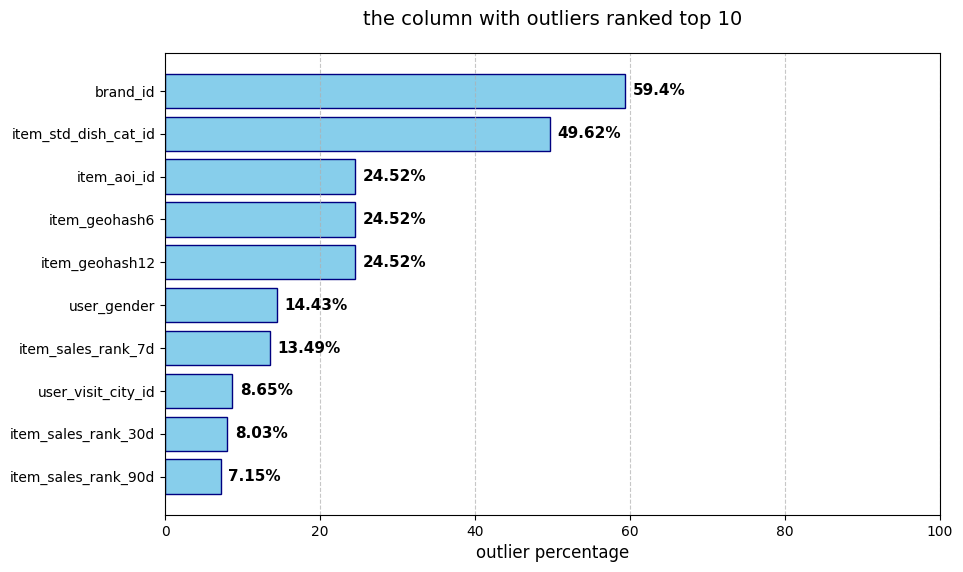

In [52]:
top_10 = sorted_missing[:10]
# 将数据反转，这样绘图时占比最高的会在最上方
top_10_reversed = top_10[::-1]

labels = [x[0] for x in top_10_reversed]
values = [x[1] for x in top_10_reversed]

# 2. 开始绘图
# 设置画布大小
plt.figure(figsize=(10, 6))

# 绘制横向条形图 (Horizontal Bar Chart)
bars = plt.barh(labels, values, color='skyblue', edgecolor='navy')

# 3. 美化图表
plt.xlabel('outlier percentage', fontsize=12)
plt.title('the column with outliers ranked top 10', fontsize=14, pad=20)
plt.xlim(0, 100)  # 设置X轴范围为 0-100%
plt.grid(axis='x', linestyle='--', alpha=0.7)

# 4. 在条形图上添加具体的百分比文字
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, 
             f'{width}%', ha='left', va='center', fontsize=11, fontweight='bold')

plt.show()

In [ ]:
## 仅查看vip类别 ，不用执行
vip_col = "is_vip"

df.groupBy(vip_col).count().orderBy(vip_col).show()

+------+------+
|is_vip| count|
+------+------+
|  NULL| 27468|
|     0|195595|
|     1|270487|
+------+------+



In [53]:
df2 = df_cleaned_rows
median_price = df2.stat.approxQuantile('user_avg_price_hist', [0.5], 0.01)[0]
if median_price is None or median_price <= 0:
    median_price = 20.0
print(median_price)

40.900001525878906


In [54]:
cat_cols = [
    'brand_id','item_std_dish_cat_id','item_aoi_id','item_geohash6','item_geohash12',
    'user_gender','user_visit_city_id'
]
# 处理类别列 unknown
for c in cat_cols:
    df2 = df2.withColumn(
        c,
        F.when(F.col(c).isNull(), F.lit('unknown')).otherwise(F.col(c).cast('string'))
    )

# B. 排名列：缺失 -> 9999
rank_cols = ['item_sales_rank_7d','item_sales_rank_30d','item_sales_rank_90d']
df2 = df2.fillna({c: 9999 for c in rank_cols})

# C. 数值列：中位数/0 填充
df2 = df2.fillna({
    'user_avg_price_hist': 40.9,
    'user_order_cnt_30d': 0,
    'user_trade_amt_30d': 0,
    'user_click_rate_30d': 0,
    'is_vip': 0
})

df_filled = df2

In [55]:
df_filled = df_filled.withColumn("user_avg_price_hist", F.col("user_avg_price_hist").cast("float"))

In [56]:
##转变时间戳
df_final = df_filled.withColumn("request_timestamp", F.from_unixtime(F.col("request_timestamp")).cast("timestamp"))

In [57]:
df_filled_show=df_final.limit(5).toPandas()
df_filled_show.head(5)

,_c0,user_id_masked,user_gender,user_visit_city_id,user_avg_price_hist,is_vip,user_click_rate_30d,user_order_cnt_30d,user_trade_amt_30d,shop_id_masked,item_id_masked,item_city_id,item_district_id,item_aoi_id,item_geohash6,item_geohash12,brand_id,item_cat1_id,item_std_dish_cat_id,item_sales_rank_7d,item_sales_rank_30d,item_sales_rank_90d,click_hist_shop_id_masked,click_hist_item_id_masked,click_hist_item_cat1_id,click_hist_item_std_dish_id,click_hist_brand_id,click_hist_item_price,click_hist_item_aoi_id,click_hist_item_geohash6,click_hist_time_diff_s,click_hist_click_hour,click_hist_click_time_slot,click_hist_click_day_of_week,request_timestamp,current_hour,current_time_slot,current_day_of_week,user_geohash12
0,0,601b640aa477c38bcdcfabc4108a6c3264123e2774cadf1266a0085076bca789,2,14,90.387779,1,139,45,4067.449951,a351d550ead292285c2b62b056ad68472fa3bcd4c0f0e1e7b9d4a8d623aefc21,4f29469f9ea86086d01eab3594650665c98f91d6fedf8a18dc858e450d5ad1dd,14,5746,B0FFG7LQ2U,wm6n3d,wm6n3dypbkqk,unknown,1066,22614,1,1,1,69b2f6a7b7b88a57ee5864995590afab7eeaf5ffd7ded0f5772a05ef2dc0a3c7;69b2f6a7b7b88a57ee5864995590afab7eeaf5ffd7ded0f5772a05ef2dc0a3c7;69b2f6a7b7b88a57ee5864995590afab7eeaf5ffd7ded0f5772a05ef2dc0a3c7;69b2f6a7b7b88a57ee5864995590afab7eeaf5ffd7ded0f5772a05ef2dc0a3c7;69b2f6a7b7b88a57ee5864995590afab7eeaf5ffd7ded0f5772a05ef2dc0a3c7;69b2f6a7b7b88a57ee5864995590afab7eeaf5ffd7ded0f5772a05ef2dc0a3c7;69b2f6a7b7b88a57ee5864995590afab7eeaf5ffd7ded0f5772a05ef2dc0a3c7;69b2f6a7b7b88a57ee5864995590afab7eeaf5ffd7ded0f5772a05ef2dc0a3c7;2509622a17c9bb563de5683afb9f905f06da60fdb043dcf65ff6926d07668037;2509622a17c9bb563de5683afb9f905f06da60fdb043dcf65ff6926d07668037;02e00be0a5710683d42ffedb29b2cc9884120aa69833133d41e1306fc6035088;146e47dfe5fc5d70017e404e2f8f31c5fb603d73ee7cd4a26c056b9b506f4f46;311a0c5f6887ccea35b1812580fee63526a978328f5ee87aa327d634cbf241f5;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300bd7c14;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300bd7c14;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300bd7c14;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300bd7c14;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300bd7c14;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300bd7c14;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300bd7c14;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300bd7c14;ca26884e5177b47452b46cc32f4d7e1677560a41025351b5e286ea615d8ed196;ca26884e5177b47452b46cc32f4d7e1677560a41025351b5e286ea615d8ed196;ca26884e5177b47452b46cc32f4d7e1677560a41025351b5e286ea615d8ed196;ca26884e5177b47452b46cc32f4d7e1677560a41025351b5e286ea615d8ed196;06dd9d5f8c72f4d74d7331effb646820ddea20d389c690b983a080417c04e0f7;06dd9d5f8c72f4d74d7331effb646820ddea20d389c690b983a080417c04e0f7;06dd9d5f8c72f4d74d7331effb646820ddea20d389c690b983a080417c04e0f7;4fd1ad2a3a431a5d986659e3e56becb7d67a7a50b6352e5c2e9eb370b36158b4;4fd1ad2a3a431a5d986659e3e56becb7d67a7a50b6352e5c2e9eb370b36158b4;4fd1ad2a3a431a5d986659e3e56becb7d67a7a50b6352e5c2e9eb370b36158b4;4fd1ad2a3a431a5d986659e3e56becb7d67a7a50b6352e5c2e9eb370b36158b4;4fd1ad2a3a431a5d986659e3e56becb7d67a7a50b6352e5c2e9eb370b36158b4;4fd1ad2a3a431a5d986659e3e56becb7d67a7a50b6352e5c2e9eb370b36158b4;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300

In [58]:
# 保存为 Parquet 文件夹
df_final.write.mode("overwrite").parquet("cleaned_data.parquet")
print("数据已成功保存为 Parquet 格式！")

数据已成功保存为 Parquet 格式！


In [ ]:
##通过Geohash可以大致比较用户和商家是否在同一区域  
##用户历史平均单价 交易金额 要改成整数
# 删除被点击的历史时间与当前时间的时间差
##AOI ID 通常是指 Area of Interest ID
## Geohash6 和 Geohash12 的核心区别在于：字符越长，代表的地理范围越精准，误差越小。
##去空值缺失值并统计
##数据透视表，建立关联表
## AI赋值
##删掉时间戳 时间戳处理
##

### 一阶段清洗结束

In [2]:
## 查看时间戳范围
df = spark.read.parquet("/root/my_proje1/tables/fact_request.parquet", header=False)
df.limit(5).show()

26/04/18 00:53:11 WARN FileStreamSink: Assume no metadata directory. Error while looking for metadata directory in the path: /root/my_proje1/tables/fact_request.parquet.
java.io.FileNotFoundException: File /root/my_proje1/tables/fact_request.parquet does not exist
	at org.apache.hadoop.fs.RawLocalFileSystem.deprecatedGetFileStatus(RawLocalFileSystem.java:980)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileLinkStatusInternal(RawLocalFileSystem.java:1301)
	at org.apache.hadoop.fs.RawLocalFileSystem.getFileStatus(RawLocalFileSystem.java:970)
	at org.apache.hadoop.fs.FilterFileSystem.getFileStatus(FilterFileSystem.java:462)
	at org.apache.spark.sql.execution.streaming.sinks.FileStreamSink$.hasMetadata(FileStreamSink.scala:58)
	at org.apache.spark.sql.execution.datasources.DataSource.resolveRelation(DataSource.scala:384)
	at org.apache.spark.sql.catalyst.analysis.ResolveDataSource.org$apache$spark$sql$catalyst$analysis$ResolveDataSource$$loadV1BatchSource(ResolveDataSource.scala:143)
	a

AnalysisException: [PATH_NOT_FOUND] Path does not exist: file:/root/my_proje1/tables/fact_request.parquet. SQLSTATE: 42K03

In [6]:
stats = df.select(
    F.min("request_timestamp").alias("min_ts"),
    F.max("request_timestamp").alias("max_ts"),
    F.sum(F.col("request_timestamp").isNull().cast("int")).alias("null_ts"),
    F.count("*").alias("row_count")
).collect()[0] # collect() 将结果拉回到驱动端

# 2. 提取结果到 Python 变量
min_ts = stats["min_ts"]
max_ts = stats["max_ts"]
null_ts = stats["null_ts"]
row_count = stats["row_count"]

# 3. 打印
print("rows:", row_count)
print("null_ts:", null_ts)
print("min_ts:", min_ts)
print("max_ts:", max_ts)

rows: 471416
null_ts: 0
min_ts: 2022-04-02 00:00:00
max_ts: 2022-04-02 23:59:56


In [68]:
df = spark.read.parquet("/root/my_proje1/cleaned_data.parquet", header=False)
df.limit(5).show()

+---+--------------------+-----------+------------------+-------------------+------+-------------------+------------------+------------------+--------------------+--------------------+------------+----------------+-----------+-------------+--------------+--------+------------+--------------------+------------------+-------------------+-------------------+-------------------------+-------------------------+-----------------------+---------------------------+--------------------+---------------------+----------------------+------------------------+----------------------+---------------------+--------------------------+----------------------------+-------------------+------------+-----------------+-------------------+--------------+
|_c0|      user_id_masked|user_gender|user_visit_city_id|user_avg_price_hist|is_vip|user_click_rate_30d|user_order_cnt_30d|user_trade_amt_30d|      shop_id_masked|      item_id_masked|item_city_id|item_district_id|item_aoi_id|item_geohash6|item_geohash12|brand

In [5]:
# 挑选出你需要检查的所有“序列型”特征列
cols = [
    "click_hist_shop_id_masked",           
    "click_hist_item_id_masked",           
    "click_hist_item_cat1_id", 
    "click_hist_brand_id",            
    "click_hist_item_price",                 
    "click_hist_item_aoi_id",           
    "click_hist_item_geohash6",                 
    "click_hist_time_diff_s",                
    "click_hist_click_time_slot",          
    "click_hist_click_day_of_week",  
]

# 只读取这些特定列，节省内存（针对你 8GB 内存的优化技巧）
df = df[cols]
df.limit(5).show()

+-------------------------+-------------------------+-----------------------+--------------------+---------------------+----------------------+------------------------+----------------------+--------------------------+----------------------------+
|click_hist_shop_id_masked|click_hist_item_id_masked|click_hist_item_cat1_id| click_hist_brand_id|click_hist_item_price|click_hist_item_aoi_id|click_hist_item_geohash6|click_hist_time_diff_s|click_hist_click_time_slot|click_hist_click_day_of_week|
+-------------------------+-------------------------+-----------------------+--------------------+---------------------+----------------------+------------------------+----------------------+--------------------------+----------------------------+
|     ed981d6330ccbe9e9...|     f42dc1eedfb3cefc0...|   1001;1210;1210;12...|0;0;0;0;0;0;0;0;0...| 2.0;23.99;23.99;1...|  -1;-1;-1;-1;B0FFG...|    y8p3fj;y8p3fj;y8p...|  87801;87859;87862...|      lunch;lunch;lunch...|        4;4;4;4;3;3;3;3;3...|
|     93

In [6]:

# 1. 定义计算长度的逻辑（兼容空值和 "null"）
def get_len(col_name):
    trimmed = F.trim(F.col(col_name))
    return F.when(
        trimmed.isNull() | (trimmed == "") | (F.lower(trimmed) == "null"), 
        0
    ).otherwise(F.size(F.split(trimmed, ";"))) # 如果你的数据是用空格分的，这里改为 " "

# 2. 批量计算所有列的长度
lens_df = df.select([get_len(c).alias(c) for c in cols])

# 3. 找出不对齐的行
base_col = "click_hist_shop_id_masked"
# 构造条件：只要有一列不等于基准列，就标记
mismatch_cond = " OR ".join([f"`{c}` != `{base_col}`" for c in cols if c != base_col])
mismatch_df = lens_df.filter(mismatch_cond)

# 4. 统计
total = df.count()
mismatch_cnt = mismatch_df.count()

print(f"总行数: {total}")
print(f"存在不对齐的行数: {mismatch_cnt}")
print(f"不对齐比例: {mismatch_cnt / total:.4f}")

if mismatch_cnt > 0:
    mismatch_df.show(5)

总行数: 484516
存在不对齐的行数: 0
不对齐比例: 0.0000


In [16]:
from pyspark.sql import functions as F

SHOP_COL = "click_hist_shop_id_masked"
ITEM_COL = "click_hist_item_id_masked"
DOW_COL  = "click_hist_click_day_of_week"
SLOT_COL = "click_hist_click_time_slot"
PRICE_COL = "click_hist_item_price"

sep = ";"

df_seq = (
    df
    .withColumn("item_arr", F.split(F.coalesce(F.col(ITEM_COL).cast("string"), F.lit("")), sep))
    .withColumn("shop_arr", F.split(F.coalesce(F.col(SHOP_COL).cast("string"), F.lit("")), sep))
    .withColumn("dow_arr",  F.split(F.coalesce(F.col(DOW_COL).cast("string"),  F.lit("")), sep))
    .withColumn("slot_arr", F.split(F.coalesce(F.col(SLOT_COL).cast("string"), F.lit("")), sep))
    .withColumn("price_arr", F.split(F.coalesce(F.col(PRICE_COL).cast("string"), F.lit("")), sep))
)

events = (
    df_seq
    .select(
        F.explode(
            F.arrays_zip(
                F.col("item_arr").alias("item_id"),
                F.col("shop_arr").alias("shop_id"),
                F.col("dow_arr").alias("day_of_week"),
                F.col("slot_arr").alias("time_slot"),
                F.col("price_arr").alias("price"),
            )
        ).alias("e")
    )
    .select(
        F.col("e.item_id").alias("item_id"),
        F.col("e.shop_id").alias("shop_id"),
        F.col("e.price").alias("price"),
        F.col("e.day_of_week").cast("int").alias("day_of_week"),
        # time_slot 为餐段等类别字符串（如 lunch），不能 cast 为 int
        F.trim(F.col("e.time_slot")).alias("time_slot"),
    )
    # 过滤空串/空值（split("") 会产生 [""]）
    .filter(
        (F.col("item_id").isNotNull()) & (F.col("item_id") != "") &
        (F.col("shop_id").isNotNull()) & (F.col("shop_id") != "")
    )
)

fact = (
    events
    .groupBy("item_id", "shop_id", "day_of_week", "time_slot")
    .agg(
        F.count(F.lit(1)).alias("click_count"),
        F.avg(F.trim(F.col("price")).cast("double")).alias("item_price"),
    )
)

fact.show(20, truncate=False)

+----------------------------------------------------------------+----------------------------------------------------------------+-----------+---------+-----------+------------------+
|item_id                                                         |shop_id                                                         |day_of_week|time_slot|click_count|item_price        |
+----------------------------------------------------------------+----------------------------------------------------------------+-----------+---------+-----------+------------------+
|e4fa2dc0b03552112f89930ea3d238d3c94c6cc90d2eddbe6e95ca51dc711a1e|a46aa960956ed27eb82cf5c44f4336983ec88769581b232e14b5cd2ed972b74f|4          |lunch    |2          |0.0               |
|6ee0b0db809c8bdb40809d2eb4576197ad6b0ffafef092b146284b12dacf0230|76b1b499acfafb2467a35e2dd8e3bfc7519b8325944f9ec17d46c35b40615254|2          |lunch    |4          |31.733333333333334|
|0ab37622dc5f6d306a0a74210456ac924e76996fcbfe1797312ffefe34485b25|8be88ff55

In [18]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# ===== 列名配置 =====
ITEM_COL = "click_hist_item_id_masked"
SHOP_COL = "click_hist_shop_id_masked"   # 与 item 序列对齐的 shop 列
DIFF_COL = "click_hist_time_diff_s"
sep = ";"

# ===== 参数（2022年）=====
BASE_DATE_STR = "2022-04-02"
NOON_BIAS_SEC = 12 * 3600
BOUNDARY_SEC = 2 * 3600
DAYS_WINDOW = 28

# 1) 拆分序列
df_seq = (
    df
    .withColumn("row_id", F.monotonically_increasing_id())
    .withColumn("item_arr", F.split(F.coalesce(F.col(ITEM_COL).cast("string"), F.lit("")), sep))
    .withColumn("shop_arr", F.split(F.coalesce(F.col(SHOP_COL).cast("string"), F.lit("")), sep))
    .withColumn("diff_arr", F.split(F.coalesce(F.col(DIFF_COL).cast("string"), F.lit("")), sep))
)

events = (
    df_seq
    .select(
        "row_id",
        F.posexplode(
            F.arrays_zip(
                F.col("item_arr").alias("item_id"),
                F.col("shop_arr").alias("shop_id"),
                F.col("diff_arr").alias("time_diff_s"),
            )
        ).alias("seq_pos", "e")
    )
    .select(
        "row_id",
        "seq_pos",
        F.trim(F.col("e.item_id")).alias("item_id"),
        F.trim(F.col("e.shop_id")).alias("shop_id"),
        F.col("e.time_diff_s").cast("double").alias("time_diff_s"),
    )
    .filter(
        F.col("item_id").isNotNull() & (F.col("item_id") != "") &
        F.col("shop_id").isNotNull() & (F.col("shop_id") != "") &
        F.col("time_diff_s").isNotNull()
    )
)

# 2) 反推日期（低算力 + 边界修正）
base_date = F.to_date(F.lit(BASE_DATE_STR))

events2 = (
    events
    .withColumn("adj_diff_s", F.col("time_diff_s") + F.lit(NOON_BIAS_SEC))
    .withColumn("days_back", F.floor(F.col("adj_diff_s") / F.lit(86400)).cast("int"))
    .filter((F.col("days_back") >= 0) & (F.col("days_back") < F.lit(DAYS_WINDOW)))
    .withColumn("event_day", F.date_sub(base_date, F.col("days_back")))
    .withColumn("sec_in_day", F.pmod(F.col("adj_diff_s").cast("long"), F.lit(86400)))
    .withColumn(
        "is_boundary",
        (F.col("sec_in_day") <= F.lit(BOUNDARY_SEC)) |
        (F.col("sec_in_day") >= F.lit(86400 - BOUNDARY_SEC))
    )
    .withColumn("day_of_week", ((F.dayofweek("event_day") + F.lit(5)) % F.lit(7)) + F.lit(1))
    .withColumn("week_idx", (F.floor(F.col("days_back") / F.lit(7)) + F.lit(1)).cast("int"))
)

# 3) 同一 row 内、同一 (item_id, shop_id) 序列上的前后差
w = Window.partitionBy("row_id", "item_id", "shop_id").orderBy("seq_pos")

delta = (
    events2
    .withColumn("next_diff_s", F.lead("time_diff_s").over(w))
    .withColumn("next_is_boundary", F.lead("is_boundary").over(w))
    .withColumn("diff_delta", F.col("time_diff_s") - F.col("next_diff_s"))
    .filter(
        F.col("next_diff_s").isNotNull() &
        (~F.col("is_boundary")) &
        (~F.col("next_is_boundary"))
    )
)

# 4) 每周每个 (item, shop) × weekday
weekly_avg = (
    delta
    .groupBy("item_id", "shop_id", "day_of_week", "week_idx")
    .agg(F.avg("diff_delta").alias("avg_diff_weekly"))
)

# 5) 主键 (item_id, shop_id, day_of_week) → avg_diff
diff_table = (
    weekly_avg
    .groupBy("item_id", "shop_id", "day_of_week")
    .agg(F.avg("avg_diff_weekly").alias("avg_diff"))
)

diff_table.show(50, truncate=False)

+----------------------------------------------------------------+----------------------------------------------------------------+-----------+-------------------+
|item_id                                                         |shop_id                                                         |day_of_week|avg_diff           |
+----------------------------------------------------------------+----------------------------------------------------------------+-----------+-------------------+
|af4d9c7998ffd3140240fb8f18464dd8804a717bad091cd091891c04fd5f7039|337129be4e61905b6cf0f01804d32cbde4666287c334bd2bec99603323427cfb|2          |-182156.0          |
|a3f3a78ab4febf200609f3287704b01bd2f7039e7a6f4fd5f0187daa3c63b537|4c511d6f1988afc13613272c61538f64562f08493693bf94e516d3c7279eeb2d|5          |-82423.0           |
|d209571a1d49bc07beffb68bf410f90628dada557748884441fd6045720985b7|7d75ca4cd5542c6af76f412b7cff36f3b69a4bfcbf8226b113e04d7804ab301e|5          |-92.0              |
|376e36d44ff1098

In [21]:
diff_table = diff_table.withColumn("avg_diff", F.abs(F.col("avg_diff")))
diff_table.show(3, truncate=False)

+----------------------------------------------------------------+----------------------------------------------------------------+-----------+--------+
|item_id                                                         |shop_id                                                         |day_of_week|avg_diff|
+----------------------------------------------------------------+----------------------------------------------------------------+-----------+--------+
|af4d9c7998ffd3140240fb8f18464dd8804a717bad091cd091891c04fd5f7039|337129be4e61905b6cf0f01804d32cbde4666287c334bd2bec99603323427cfb|2          |182156.0|
|a3f3a78ab4febf200609f3287704b01bd2f7039e7a6f4fd5f0187daa3c63b537|4c511d6f1988afc13613272c61538f64562f08493693bf94e516d3c7279eeb2d|5          |82423.0 |
|d209571a1d49bc07beffb68bf410f90628dada557748884441fd6045720985b7|7d75ca4cd5542c6af76f412b7cff36f3b69a4bfcbf8226b113e04d7804ab301e|5          |92.0    |
+----------------------------------------------------------------+----------------

In [9]:
print(fact.count())

13103166


In [69]:
from pyspark.sql import functions as F

sep = ";"

# 与你 homework 一致的列（按实际表改）
ITEM_COL = "click_hist_item_id_masked"
SHOP_COL = "click_hist_shop_id_masked"
BRAND_COL = "click_hist_brand_id"          
CAT1_COL = "click_hist_item_cat1_id"  
AOI_COL = "click_hist_item_aoi_id"        
GEO_COL = "click_hist_item_geohash6"      

df_seq = (
    df
    .withColumn("item_arr", F.split(F.coalesce(F.col(ITEM_COL).cast("string"), F.lit("")), sep))
    .withColumn("shop_arr", F.split(F.coalesce(F.col(SHOP_COL).cast("string"), F.lit("")), sep))
    .withColumn("brand_arr", F.split(F.coalesce(F.col(BRAND_COL).cast("string"), F.lit("")), sep))
    .withColumn("cat1_arr", F.split(F.coalesce(F.col(CAT1_COL).cast("string"), F.lit("")), sep))
    .withColumn("aoi_arr", F.split(F.coalesce(F.col(AOI_COL).cast("string"), F.lit("")), sep))
    .withColumn("geo_arr", F.split(F.coalesce(F.col(GEO_COL).cast("string"), F.lit("")), sep))
)

events = (
    df_seq
    .select(
        F.explode(
            F.arrays_zip(
                F.col("item_arr").alias("item_id"),
                F.col("shop_arr").alias("shop_id"),
                F.col("brand_arr").alias("brand_id"),
                F.col("cat1_arr").alias("item_cat1_id"),
                F.col("aoi_arr").alias("item_aoi"),
                F.col("geo_arr").alias("item_geohash6"),
            )
        ).alias("e")
    )
    .select(
        F.trim(F.col("e.item_id")).alias("item_id"),
        F.trim(F.col("e.shop_id")).alias("shop_id"),
        F.trim(F.col("e.brand_id")).alias("brand_id"),
        F.trim(F.col("e.item_cat1_id")).alias("item_cat1_id"),
        F.trim(F.col("e.item_aoi")).alias("item_aoi"),
        F.trim(F.col("e.item_geohash6")).alias("item_geohash6"),
    )
    .filter(
        F.col("item_id").isNotNull() & (F.col("item_id") != "") &
        F.col("shop_id").isNotNull() & (F.col("shop_id") != "")
    )
)

# 主键 (item_id, shop_id)：同一对多次出现取第一条（若有多值需改口径为 max/众数等）
item_table = (
    events
    .groupBy("item_id", "shop_id")
    .agg(
        F.first("brand_id").alias("brand_id"),
        F.first("item_cat1_id").alias("item_cat1_id"),
    )
)

geo_table = (
    events
    .groupBy("item_id", "shop_id")
    .agg(
        F.first("item_aoi").alias("item_aoi"),
        F.first("item_geohash6").alias("item_geohash6"),
    )
)

item_table.show(20, truncate=False)
geo_table.show(20, truncate=False)

+----------------------------------------------------------------+----------------------------------------------------------------+--------+------------+
|item_id                                                         |shop_id                                                         |brand_id|item_cat1_id|
+----------------------------------------------------------------+----------------------------------------------------------------+--------+------------+
|000013f7ae836353849924ecbb29986b0a207c9df2ffed5b985bc7663447a571|144a38864179d844a38bc86813c6e9dca46405e77d731d07313ac93c028123fa|1015859 |1001        |
|00005990d0270c595bf934962e83010d687c17a2cc2a36e416b5d76de07c1259|b48827ecabcda8c9c04fb609dafbe5cebe36d43106b11f5e5495c9d990bd0996|1049707 |1210        |
|0000617e4c651fd39c20439b7a1a9df312c22157ca98de332fa0765e946a02c0|db4a1914530ddc27a639a184b3c41d54b2ace01a40016fb26b5d40fe50e0c1bb|624841  |1099        |
|000088de529219f54d38e8e8d709dccea695a01a7bc7ed62b81f51f929e1dd2b|88dc50921d

+----------------------------------------------------------------+----------------------------------------------------------------+----------+-------------+
|item_id                                                         |shop_id                                                         |item_aoi  |item_geohash6|
+----------------------------------------------------------------+----------------------------------------------------------------+----------+-------------+
|000013f7ae836353849924ecbb29986b0a207c9df2ffed5b985bc7663447a571|144a38864179d844a38bc86813c6e9dca46405e77d731d07313ac93c028123fa|B023A0I79V|wth775       |
|00005990d0270c595bf934962e83010d687c17a2cc2a36e416b5d76de07c1259|b48827ecabcda8c9c04fb609dafbe5cebe36d43106b11f5e5495c9d990bd0996|B02CE0P84E|wmmu5v       |
|0000617e4c651fd39c20439b7a1a9df312c22157ca98de332fa0765e946a02c0|db4a1914530ddc27a639a184b3c41d54b2ace01a40016fb26b5d40fe50e0c1bb|-1        |ws06t3       |
|000088de529219f54d38e8e8d709dccea695a01a7bc7ed62b81f51f92

In [29]:
print(item_table.count())

8482469


In [70]:
import os

ITEM_ANALYSIS_DIR = "/root/my_proje1/item_analysis"
os.makedirs(ITEM_ANALYSIS_DIR, exist_ok=True)

# 四张表各写入一个 Parquet 子目录
for name, tbl in [
    ("item_table", item_table),
    ("geo_table", geo_table),
]:
    path = os.path.join(ITEM_ANALYSIS_DIR, name)
    tbl.write.mode("overwrite").parquet(path)
    print("saved:", path)

saved: /root/my_proje1/item_analysis/item_table


saved: /root/my_proje1/item_analysis/geo_table


In [22]:
import os

ITEM_ANALYSIS_DIR = "/root/my_proje1/item_analysis"
os.makedirs(ITEM_ANALYSIS_DIR, exist_ok=True)

# 四张表各写入一个 Parquet 子目录
for name, tbl in [
    ("fact", fact),
    ("item_table", item_table),
    ("diff_table", diff_table),
    ("geo_table", geo_table),
]:
    path = os.path.join(ITEM_ANALYSIS_DIR, name)
    tbl.write.mode("overwrite").parquet(path)
    print("saved:", path)

saved: /root/my_proje1/item_analysis/fact


saved: /root/my_proje1/item_analysis/item_table


saved: /root/my_proje1/item_analysis/diff_table


saved: /root/my_proje1/item_analysis/geo_table


#### 二轮数据清洗开始

In [27]:
df_fact=spark.read.parquet("/root/my_proje1/item_analysis/fact")
df_fact.show(5, truncate=False)

+----------------------------------------------------------------+----------------------------------------------------------------+-----------+---------+-----------+----------+
|item_id                                                         |shop_id                                                         |day_of_week|time_slot|click_count|item_price|
+----------------------------------------------------------------+----------------------------------------------------------------+-----------+---------+-----------+----------+
|e0c27a51494512700bf6db49c0b709b964c0cb0e8927b2851eac57d96dbac28f|8a4f893083afdb5324ca24a02bda968f37d3814109e5185cdbaa64fbc04cdeb4|3          |dinner   |2          |2.0       |
|13a68b94876c2d35912dd5168532c1bbe94108b6b5644aabad3353b3598281fa|5cf26b4a2f4e7069133547ba96a8143f532f90d35fafc0ff9e55cbe2b53f9e9f|6          |lunch    |1          |0.7       |
|d177afe9442e030977761662696a839075eacd8080d22411ed430b56f2110b6c|2253828a8ce087fccd227ea8d056941a79995c2e8e55aba12

In [28]:
print(df_fact.count())

13103166


In [ ]:
col = "time_slot"

df_fact.groupBy(col).count().orderBy(col).show()

+---------+-------+
|time_slot|  count|
+---------+-------+
|breakfast| 898055|
|   dinner|4671512|
|    lunch|4392557|
|    night|1927458|
|      tea|1213584|
+---------+-------+



In [32]:
col = "day_of_week"

df_fact.groupBy(col).count().orderBy(col).show()

+-----------+-------+
|day_of_week|  count|
+-----------+-------+
|          0|1441334|
|          1|1579999|
|          2|1682565|
|          3|1928503|
|          4|2221842|
|          5|2638994|
|          6|1609929|
+-----------+-------+



In [66]:
df_diff=spark.read.parquet("/root/my_proje1/item_analysis/diff_table")
df_diff.show(5, truncate=False)

+----------------------------------------------------------------+----------------------------------------------------------------+-----------+--------+
|item_id                                                         |shop_id                                                         |day_of_week|avg_diff|
+----------------------------------------------------------------+----------------------------------------------------------------+-----------+--------+
|d93a5456ee0663e8416ee113713012321402d26aa0a6ce2b1669e76cf09f18b1|cc866cd74e58fb2bece1c334cb4554d129ce9f56cb54c9255127478b13afd903|6          |29665.0 |
|ed603c62cc4078051d0d91fb6b42e7806372dec81ede1ea2ae5ebd18eb68fc80|76600c03887a679dceb2b79c5357803521a6fb2ea7a2b787bd2b94e0baeb789d|6          |1071.0  |
|a4d05dab1c3b97211e8ccbe8721fc44919afeb96cd51aab1c11d1fd9048ae978|4b734bf72b539ad2a80e84e019d231da8e28d7ea8ab7f881152b94a40660eb8c|5          |991406.0|
|f8eca08a152ec06f9361f579e68f038bf1c834cfdff14c772a254c33a6452127|bb39b8809459a59e

In [71]:
df_item=spark.read.parquet("/root/my_proje1/item_analysis/item_table")
df_item.show(5, truncate=False)

+----------------------------------------------------------------+----------------------------------------------------------------+--------+------------+
|item_id                                                         |shop_id                                                         |brand_id|item_cat1_id|
+----------------------------------------------------------------+----------------------------------------------------------------+--------+------------+
|000028b14c337fe8156a65d43ba50f6e50c0da849891dfc32beb01260a89f6d1|c5306de404ad9b08e2c40abb8b2bb34780f8c209174f3f49b58b4eac313410ea|0       |1059        |
|00007bccdd34c6d3d17290bb5f754c0f61cc93890a1a0b99c530708baedfd15c|e4b7ddfe1d46ee68b4f8fd9b216046ff3df9ecb63adfa0692d4c6c794ff917ef|5242    |1087        |
|0000894bcaa2b9f3d7a5619b3e012547882d87148ce8c95061861f2c408ffcd8|b63f158ef28796ffab8a538f1a035ab72124fa52172dc7b1757dfcc82b2d230d|0       |1059        |
|0001178bcf692507326d846965e828b9229ab32cfaa6e6b18fbbfca76d1198cb|e0d157b0a0

In [60]:
cols = [   
    "brand_id",
    "item_cat1_id"
]

# 2. 获取剩下的需要统计的列
cols_to_check = [c for c in df_item.columns if c in cols]

# 3. 构造统计指令
stats = []
for c in cols_to_check:
    # 统计 Null 值
    stats.append(F.count(F.when(F.col(c).isNull(), c)).alias(f"{c}_Null"))
    # 统计 -1 (转为字符串比较以防报错)
    stats.append(F.count(F.when(F.col(c).cast("string") == "-1", c)).alias(f"{c}_-1"))
    stats.append(F.count(F.when(F.col(c).cast("string") == "0", c)).alias(f"{c}_0"))
    stats.append(F.count(F.when(F.col(c).cast("string") == "-99", c)).alias(f"{c}_-99"))
    
# 4. 执行统计并逐列打印（避免 show(vertical=True) 因 maxToStringFields 省略 ...）
print(f"正在统计 {len(cols_to_check)} 列的异常值（Null,-1）...")
missing_df = df_item.select(stats)
_row = missing_df.collect()[0]
_w = max(len(c) for c in missing_df.columns)
for _c in missing_df.columns:
    print(f"{_c:{_w}s} | {_row[_c]}")

正在统计 2 列的异常值（Null,-1）...


brand_id_Null     | 0
brand_id_-1       | 0
brand_id_0        | 4640058
brand_id_-99      | 0
item_cat1_id_Null | 0
item_cat1_id_-1   | 0
item_cat1_id_0    | 11663
item_cat1_id_-99  | 0


In [61]:
N = df_item.count()
brand_id_0 = 4640058
item_cat1_id_0 = 11663

p_brand = brand_id_0 / N
p_cat1 = item_cat1_id_0 / N

print("N =", N)
print("brand_id=0 占比:", p_brand, f"({p_brand*100:.4f}%)")
print("item_cat1_id=0 占比:", p_cat1, f"({p_cat1*100:.4f}%)")

N = 8482469
brand_id=0 占比: 0.5470173837357968 (54.7017%)
item_cat1_id=0 占比: 0.0013749534481057343 (0.1375%)


In [72]:
update_exprs = [
    (
        F.when(
             (F.col(c).cast("string") == "0") & F.lit(c in cols_to_check),
            F.lit(None),
        ).otherwise(F.col(c)).alias(c)
    )
    for c in df_item.columns
]

# 2. 执行替换（产生新的 df）
df_item = df_item.select(*update_exprs)


In [73]:
df_geo=spark.read.parquet("/root/my_proje1/item_analysis/geo_table")
df_geo.show(5, truncate=False)

+----------------------------------------------------------------+----------------------------------------------------------------+----------+-------------+
|item_id                                                         |shop_id                                                         |item_aoi  |item_geohash6|
+----------------------------------------------------------------+----------------------------------------------------------------+----------+-------------+
|000028b14c337fe8156a65d43ba50f6e50c0da849891dfc32beb01260a89f6d1|c5306de404ad9b08e2c40abb8b2bb34780f8c209174f3f49b58b4eac313410ea|B02550OKRF|ws7nw8       |
|00007bccdd34c6d3d17290bb5f754c0f61cc93890a1a0b99c530708baedfd15c|e4b7ddfe1d46ee68b4f8fd9b216046ff3df9ecb63adfa0692d4c6c794ff917ef|-1        |wsv7rr       |
|0000894bcaa2b9f3d7a5619b3e012547882d87148ce8c95061861f2c408ffcd8|b63f158ef28796ffab8a538f1a035ab72124fa52172dc7b1757dfcc82b2d230d|B000A882D3|wx4fz3       |
|0001178bcf692507326d846965e828b9229ab32cfaa6e6b18fbbfca76

In [74]:
df_geo=df_geo.drop("item_aoi")

In [75]:
import pygeohash as pgh
from pyspark.sql.types import StructType, StructField, DoubleType

@F.udf(StructType([
    StructField("lat", DoubleType(), True),
    StructField("lon", DoubleType(), True),
]))
def geohash6_to_latlon(g):
    if g is None:
        return None
    s = str(g).strip()
    if s == "" or s.lower() in ("null", "none", "-1"):
        return None
    try:
        lat, lon = pgh.decode(s)
        return (float(lat), float(lon))
    except Exception:
        return None

df_geo = df_geo.withColumn("geo", geohash6_to_latlon(F.col("item_geohash6"))) \
    .withColumn("lat", F.col("geo.lat")) \
    .withColumn("lon", F.col("geo.lon")) \
    .drop("geo")

In [76]:
df_geo=df_geo.drop("item_geohash6")
df_geo = df_geo.withColumn("lat", F.round(F.col("lat"), 5)) \
       .withColumn("lon", F.round(F.col("lon"), 5))

In [77]:
df_geo.show(5, truncate=False)

+----------------------------------------------------------------+----------------------------------------------------------------+--------+---------+
|item_id                                                         |shop_id                                                         |lat     |lon      |
+----------------------------------------------------------------+----------------------------------------------------------------+--------+---------+
|000028b14c337fe8156a65d43ba50f6e50c0da849891dfc32beb01260a89f6d1|c5306de404ad9b08e2c40abb8b2bb34780f8c209174f3f49b58b4eac313410ea|25.05157|117.00989|
|00007bccdd34c6d3d17290bb5f754c0f61cc93890a1a0b99c530708baedfd15c|e4b7ddfe1d46ee68b4f8fd9b216046ff3df9ecb63adfa0692d4c6c794ff917ef|27.33124|120.20691|
|0000894bcaa2b9f3d7a5619b3e012547882d87148ce8c95061861f2c408ffcd8|b63f158ef28796ffab8a538f1a035ab72124fa52172dc7b1757dfcc82b2d230d|39.86664|116.69128|
|0001178bcf692507326d846965e828b9229ab32cfaa6e6b18fbbfca76d1198cb|e0d157b0a031c0affeffd819a823

In [78]:
ITEM_ANALYSIS_DIR = "/root/my_proje1/item_analysis"
os.makedirs(ITEM_ANALYSIS_DIR, exist_ok=True)

# 四张表各写入一个 Parquet 子目录
for name, tbl in [
    ("item_table2", df_item),
    ("geo_table2", df_geo),
]:
    path = os.path.join(ITEM_ANALYSIS_DIR, name)
    tbl.write.mode("overwrite").parquet(path)
    print("saved:", path)

saved: /root/my_proje1/item_analysis/item_table2


saved: /root/my_proje1/item_analysis/geo_table2


#### 上面两段代码计算day_of_week和time_slot是否有缺失值或异常值，检查出来正常

In [33]:
## 查看-99值
cols = [    
    'click_count',
    'item_price'
]

# 2. 获取剩下的需要统计的列
cols_to_check = [c for c in df_fact.columns if c in cols]

# 3. 构造统计指令
stats = []
for c in cols_to_check:
    stats.append(F.count(F.when(F.col(c).cast("string") == "-99", c)).alias(f"{c}_99"))
    stats.append(F.count(F.when(F.col(c).cast("string") == "0", c)).alias(f"{c}_0"))
    stats.append(F.count(F.when(F.col(c).cast("string") == "-1", c)).alias(f"{c}_-1"))
    stats.append(F.count(F.when(F.col(c).isNull(), c)).alias(f"{c}_null"))

print(f"正在统计 {len(cols_to_check)} 列的异常值（-99）...")
missing_df = df_fact.select(stats)
missing_df2=missing_df.toPandas().T
missing_df2

正在统计 2 列的异常值（-99）...


,0
click_count_99,0
click_count_0,0
click_count_-1,0
click_count_null,0
item_price_99,0
item_price_0,0
item_price_-1,0
item_price_null,0


### 以下是对比代码

In [5]:
hist_cols = [
    "click_hist_shop_id_masked",
    "click_hist_item_id_masked",
    "click_hist_item_cat1_id",
    "click_hist_item_std_dish_id",
    "click_hist_brand_id",
    "click_hist_item_price",
    "click_hist_item_aoi_id",
    "click_hist_item_geohash6",
    "click_hist_click_hour",
    "click_hist_click_time_slot",
    "click_hist_click_day_of_week",
]

def str_to_array(col_name: str):
    s = F.trim(F.col(col_name))
    # 空串 -> 空数组；否则按分号拆分
    return F.when(s == "", F.array()).otherwise(F.split(s, ";"))

for c in hist_cols:
    df = df.withColumn(c, str_to_array(c))

In [6]:
df.limit(5).show()

+--------------------+-----------+------------------+-------------------+------+-------------------+------------------+------------------+--------------------+--------------------+------------+----------------+-----------+-------------+--------------+--------+------------+--------------------+------------------+-------------------+-------------------+-------------------------+-------------------------+-----------------------+---------------------------+--------------------+---------------------+----------------------+------------------------+---------------------+--------------------------+----------------------------+-------------------+------------+-----------------+-------------------+--------------+
|      user_id_masked|user_gender|user_visit_city_id|user_avg_price_hist|is_vip|user_click_rate_30d|user_order_cnt_30d|user_trade_amt_30d|      shop_id_masked|      item_id_masked|item_city_id|item_district_id|item_aoi_id|item_geohash6|item_geohash12|brand_id|item_cat1_id|item_std_dish_

In [ ]:
df.write.mode("overwrite").parquet("cleaned_data.parquet")
print("数据已成功保存为 Parquet 格式！")

In [ ]:
# 用户表：记录用户的静态/长期属性
user_cols = [
    "user_id_masked", "user_gender", "user_visit_city_id", 
    "user_avg_price_hist", "is_vip", "user_click_rate_30d", 
    "user_order_cnt_30d", "user_trade_amt_30d"
]

# 商品与店铺表：记录商品的品牌、类目、排名和地理信息
item_cols = [
    "item_id_masked", "shop_id_masked", "item_city_id", 
    "item_district_id", "item_aoi_id", "item_geohash6", 
    "item_geohash12", "brand_id", "item_cat1_id", 
    "item_std_dish_cat_id", "item_sales_rank_7d", 
    "item_sales_rank_30d", "item_sales_rank_90d"
]

# 上下文与行为序列表：记录每次请求时的环境和历史点击流
behavior_cols = [
    "user_id_masked", "item_id_masked", "request_timestamp", 
    "current_hour", "current_time_slot", "current_day_of_week", 
    "user_geohash12", "click_hist_item_id_masked", "click_hist_item_cat1_id", 
    "click_hist_item_std_dish_id", "click_hist_brand_id", "click_hist_item_price", 
    "click_hist_item_aoi_id", "click_hist_item_geohash6", "click_hist_click_hour", 
    "click_hist_click_time_slot", "click_hist_click_day_of_week"
]

In [ ]:
# 用户表和商品表需要 distinct()，因为同一个用户/商品在原始 50 万行中会出现多次
df_user = df_final.select(user_cols).distinct()
df_item = df_final.select(item_cols).distinct()

# 行为表不需要去重，因为它代表了每一条真实的点击/请求记录
df_behavior = df_final.select(behavior_cols)


In [ ]:
df_user.write.mode("overwrite").option("header","true").csv("data_warehouse/user_profile2.csv")
# 导出商品表
df_item.write.mode("overwrite").option("header","true").csv("data_warehouse/item_profile2.csv")
# 导出交互行为表
df_behavior.write.mode("overwrite").option("header","true").csv("data_warehouse/user_behavior_context2.csv")

print("✅ 三张表已成功导出至 'data_warehouse' 文件夹中！")

# --- 4. 验证：查看拆分后的规模 ---
print(f"原始记录总数: {df_final.count()}")
print(f"独立用户总数: {df_user.count()}")
print(f"独立商品总数: {df_item.count()}")

✅ 三张表已成功导出至 'data_warehouse' 文件夹中！


原始记录总数: 500000


独立用户总数: 400779


独立商品总数: 311852


In [ ]:
df_cleaned = spark.read.parquet("/root/my_proje1/cleaned_data.parquet")
df_cleaned.limit(5).show()


+--------------------+-----------+------------------+-------------------+------+-------------------+------------------+------------------+--------------------+--------------------+------------+----------------+-----------+-------------+--------------+--------+------------+--------------------+------------------+-------------------+-------------------+-------------------------+-------------------------+-----------------------+---------------------------+--------------------+---------------------+----------------------+------------------------+---------------------+--------------------------+----------------------------+-------------------+------------+-----------------+-------------------+--------------+
|      user_id_masked|user_gender|user_visit_city_id|user_avg_price_hist|is_vip|user_click_rate_30d|user_order_cnt_30d|user_trade_amt_30d|      shop_id_masked|      item_id_masked|item_city_id|item_district_id|item_aoi_id|item_geohash6|item_geohash12|brand_id|item_cat1_id|item_std_dish_

In [ ]:
df_cleaned2 = df_cleaned.withColumn("request_timestamp", F.date_trunc("minute", F.col("request_timestamp")))

In [ ]:
df_cleaned2 = df_cleaned2.withColumn(
    "brand_id",
    F.when(F.col("brand_id").cast("string") == "unknown", F.lit(None))
     .otherwise(F.col("brand_id"))
).withColumn(
    "user_gender",
    F.when(F.trim(F.col("user_gender").cast("string")) == "-99", F.lit(None))
     .otherwise(F.col("user_gender"))
)


In [ ]:
df_cleaned2.limit(5).show()

+--------------------+-----------+------------------+-------------------+------+-------------------+------------------+------------------+--------------------+--------------------+------------+----------------+-----------+-------------+--------------+--------+------------+--------------------+------------------+-------------------+-------------------+-------------------------+-------------------------+-----------------------+---------------------------+--------------------+---------------------+----------------------+------------------------+---------------------+--------------------------+----------------------------+-------------------+------------+-----------------+-------------------+--------------+
|      user_id_masked|user_gender|user_visit_city_id|user_avg_price_hist|is_vip|user_click_rate_30d|user_order_cnt_30d|user_trade_amt_30d|      shop_id_masked|      item_id_masked|item_city_id|item_district_id|item_aoi_id|item_geohash6|item_geohash12|brand_id|item_cat1_id|item_std_dish_

### 以下是四张表检验

In [8]:
df_fact=spark.read.parquet("/root/my_proje1/item_analysis/fact")
df_fact.show(5, truncate=False)

+----------------------------------------------------------------+----------------------------------------------------------------+-----------+---------+-----------+----------+
|item_id                                                         |shop_id                                                         |day_of_week|time_slot|click_count|item_price|
+----------------------------------------------------------------+----------------------------------------------------------------+-----------+---------+-----------+----------+
|e0c27a51494512700bf6db49c0b709b964c0cb0e8927b2851eac57d96dbac28f|8a4f893083afdb5324ca24a02bda968f37d3814109e5185cdbaa64fbc04cdeb4|3          |dinner   |2          |2.0       |
|13a68b94876c2d35912dd5168532c1bbe94108b6b5644aabad3353b3598281fa|5cf26b4a2f4e7069133547ba96a8143f532f90d35fafc0ff9e55cbe2b53f9e9f|6          |lunch    |1          |0.7       |
|d177afe9442e030977761662696a839075eacd8080d22411ed430b56f2110b6c|2253828a8ce087fccd227ea8d056941a79995c2e8e55aba12

In [7]:
df_item=spark.read.parquet("/root/my_proje1/item_analysis/item_table2")
df_item.show(5, truncate=False)

+----------------------------------------------------------------+----------------------------------------------------------------+--------+------------+
|item_id                                                         |shop_id                                                         |brand_id|item_cat1_id|
+----------------------------------------------------------------+----------------------------------------------------------------+--------+------------+
|000042100df3032938eea054807f5dab613e716251067a540cc22771fc323d87|b9dc90e67e6909582ca9827d5af9a54e554b59a378a0a3abd456ac25b2917f64|NULL    |1001        |
|0000c3b8c5c62baec1cfa791e28aa1f13299cef3626f4895fdd54e9e2a78a490|4c8868f62c1d26686353ba8187bcf8c36df561647be095cf03493c2d5013cd2d|NULL    |1106        |
|0000e942712e9f4767b00d418cc567ae3ace11769f0f734a5d1da8e8c8a861d2|ab29b9ec7440e6f8a8221d6f3d09bac5d76a9ac56902cfa36f370e82dabfd4be|NULL    |1210        |
|0001557f565e73ef09ced00843ef9d13342abe4612ba5f48e9ab6e3193526ba0|2e34ec61a0

In [9]:
df_geo=spark.read.parquet("/root/my_proje1/item_analysis/geo_table2")
df_geo.show(5, truncate=False)

+----------------------------------------------------------------+----------------------------------------------------------------+--------+---------+
|item_id                                                         |shop_id                                                         |lat     |lon      |
+----------------------------------------------------------------+----------------------------------------------------------------+--------+---------+
|000003400f204632606932afb05eff80fecc92defb640aabf353e53de5e8d84c|7404749650b8dac8e4453121f5da530e1254073458637c6b1bf962b83a568063|30.78644|103.95813|
|000078207677c00835257735201eae9a8578a67d448d30559b4240b020fbd9e7|5d8a2d015c02bdc7d5d49533635916d3de31857a80b7e546f7717dd0817cbf33|40.01495|116.35071|
|00008edeaaeeb3f019f37ba9f4b9025696aa8cd3f9872c2da303a8effe79ea03|5b8be71600a23b9639f0f7884567f709d22b14ed4e6b01aaee7efafa3a9bc570|31.89606|120.94299|
|0001575e425a78d826c7647778967b5a6a4a5316bb35fe399c106f2c000766ef|e7b8b992cf2ebea402dd29f283c0

In [11]:
df_diff=spark.read.parquet("/root/my_proje1/item_analysis/diff_table")
df_diff.show(5, truncate=False)

+----------------------------------------------------------------+----------------------------------------------------------------+-----------+--------+
|item_id                                                         |shop_id                                                         |day_of_week|avg_diff|
+----------------------------------------------------------------+----------------------------------------------------------------+-----------+--------+
|d93a5456ee0663e8416ee113713012321402d26aa0a6ce2b1669e76cf09f18b1|cc866cd74e58fb2bece1c334cb4554d129ce9f56cb54c9255127478b13afd903|6          |29665.0 |
|ed603c62cc4078051d0d91fb6b42e7806372dec81ede1ea2ae5ebd18eb68fc80|76600c03887a679dceb2b79c5357803521a6fb2ea7a2b787bd2b94e0baeb789d|6          |1071.0  |
|a4d05dab1c3b97211e8ccbe8721fc44919afeb96cd51aab1c11d1fd9048ae978|4b734bf72b539ad2a80e84e019d231da8e28d7ea8ab7f881152b94a40660eb8c|5          |991406.0|
|f8eca08a152ec06f9361f579e68f038bf1c834cfdff14c772a254c33a6452127|bb39b8809459a59e

### 下面是RFM表改良版构建及参数运算

In [9]:
df = spark.read.parquet("/root/my_proje1/cleaned_data.parquet")
df.show(5, truncate=False)

+---+----------------------------------------------------------------+-----------+------------------+-------------------+------+-------------------+------------------+------------------+----------------------------------------------------------------+----------------------------------------------------------------+------------+----------------+-----------+-------------+--------------+--------+------------+--------------------+------------------+-------------------+-------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [10]:
df = df.select('user_id_masked','user_order_cnt_30d','click_hist_shop_id_masked','click_hist_item_id_masked'
,'click_hist_item_cat1_id','click_hist_time_diff_s','user_click_rate_30d','user_trade_amt_30d','current_hour')

In [6]:
print(len(df.columns))

9


In [7]:
## 计算
df.show(5, truncate=False)

+----------------------------------------------------------------+------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

##### 因为user_id有重复值，所以合并其行为序列

In [11]:
seq_cols = [
    "click_hist_shop_id_masked",
    "click_hist_item_id_masked",
    "click_hist_item_cat1_id",
    "click_hist_time_diff_s",
]

# 把每列的多行字符串拼接起来（过滤 NULL/空串）
def merge_seq(colname: str):
    c = F.col(colname)
    non_empty = F.when(c.isNull() | (F.trim(c) == ""), F.lit(None)).otherwise(c)
    return F.concat_ws(";", F.collect_list(non_empty)).alias(colname)

df_user = (
    df.groupBy("user_id_masked")
      .agg(
          F.max("user_order_cnt_30d").alias("user_order_cnt_30d"),
          F.max("user_trade_amt_30d").alias("user_trade_amt_30d"),
          F.max("user_click_rate_30d").alias("user_click_rate_30d"),
          F.max("current_hour").alias("current_hour"),
          *[merge_seq(c) for c in seq_cols],
      )
)

In [12]:
df2=df_user

In [13]:
row_clicks = F.when(
    F.col("click_hist_shop_id_masked").isNull() | (F.trim(F.col("click_hist_shop_id_masked")) == ""),
    F.lit(0),
).otherwise(F.size(F.split(F.col("click_hist_shop_id_masked"), ";")))
df2 = df2.withColumn("click_cnt_30d", row_clicks)

In [14]:
df2.show(5, truncate=False)

+----------------------------------------------------------------+------------------+------------------+-------------------+------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [15]:
## 这里过滤掉无数值的行
df= df2.filter(F.col("click_cnt_30d") > 0)

In [16]:
df.count()


382507

In [ ]:
cur_h = F.col("current_hour").cast("double")

df2 = (
    df.withColumn(
        "click_hist_time_diff_day",
        F.when(
            F.col("click_hist_time_diff_s").isNull() | (F.trim(F.col("click_hist_time_diff_s")) == ""),
            F.lit(None),
        ).otherwise(
            F.concat_ws(
                ";",
                F.expr(
                    """
                    transform(
                      split(click_hist_time_diff_s, ';'),
                      x -> cast((cast(x as double)/3600 - cast(current_hour as double))/24 as string)
                    )
                    """
                ),
            )
        ),
    )
)

In [18]:
df2.show(5, truncate=False)

+----------------------------------------------------------------+------------------+------------------+-------------------+------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [19]:
df2 = df2.withColumn(
    "click_hist_active_days",
    F.when(
        F.col("click_hist_time_diff_day").isNull() | (F.trim(F.col("click_hist_time_diff_day")) == ""),
        F.lit(None),
    ).otherwise(
        F.concat_ws(
            ";",
            F.expr(
                """
                transform(
                  filter(
                    split(click_hist_time_diff_day, ';'),
                    x -> cast(x as double) >= 0
                  ),
                  y -> cast(round(cast(y as double), 0) as int)
                )
                """
            ),
        )
    ),
)

In [20]:
df2.show(5, truncate=False)

+----------------------------------------------------------------+------------------+------------------+-------------------+------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [21]:
df2 = df2.withColumn(
    "click_days_30d",
    F.when(
        F.col("click_hist_active_days").isNull() | (F.trim(F.col("click_hist_active_days")) == ""),
        F.lit(0),
    ).otherwise(
        F.size(
            F.array_distinct(
                F.split(F.col("click_hist_active_days"), ";")
            )
        )
    ),
)

In [23]:
df2.show(5)

+--------------------+------------------+------------------+-------------------+------------+-------------------------+-------------------------+-----------------------+----------------------+-------------+------------------------+----------------------+--------------+
|      user_id_masked|user_order_cnt_30d|user_trade_amt_30d|user_click_rate_30d|current_hour|click_hist_shop_id_masked|click_hist_item_id_masked|click_hist_item_cat1_id|click_hist_time_diff_s|click_cnt_30d|click_hist_time_diff_day|click_hist_active_days|click_days_30d|
+--------------------+------------------+------------------+-------------------+------------+-------------------------+-------------------------+-----------------------+----------------------+-------------+------------------------+----------------------+--------------+
|0000ee55b97fa2e84...|                51|           2524.26|                247|           9|     50f13d278bd110f2f...|     36b6b270e008d6a8d...|   1001;1210;1210;12...|  26302;26352;60554..

In [24]:
df2 = df2.withColumn(
    "avg_click_per_active_day",
    F.when(
        F.col("click_days_30d").isNull() | (F.col("click_days_30d") == 0),
        F.lit(None), 
    ).otherwise(
        F.col("click_cnt_30d").cast("double") / F.col("click_days_30d").cast("double")
    ),
)

In [25]:
df2.show(5)

+--------------------+------------------+------------------+-------------------+------------+-------------------------+-------------------------+-----------------------+----------------------+-------------+------------------------+----------------------+--------------+------------------------+
|      user_id_masked|user_order_cnt_30d|user_trade_amt_30d|user_click_rate_30d|current_hour|click_hist_shop_id_masked|click_hist_item_id_masked|click_hist_item_cat1_id|click_hist_time_diff_s|click_cnt_30d|click_hist_time_diff_day|click_hist_active_days|click_days_30d|avg_click_per_active_day|
+--------------------+------------------+------------------+-------------------+------------+-------------------------+-------------------------+-----------------------+----------------------+-------------+------------------------+----------------------+--------------+------------------------+
|0000ee55b97fa2e84...|                51|           2524.26|                247|           9|     50f13d278bd110f2f

In [28]:
df2 = df2.withColumn(
    "distinct_shop_30d",
    F.when(
        F.col("click_hist_shop_id_masked").isNull() | (F.trim(F.col("click_hist_shop_id_masked")) == ""),
        F.lit(None),
    ).otherwise(
        F.size(
            F.array_distinct(
                F.split(F.col("click_hist_shop_id_masked"), ";")
            )
        )
    ),
)

df2 = df2.withColumn(
    "distinct_item_30d",
    F.when(
        F.col("click_hist_item_id_masked").isNull() | (F.trim(F.col("click_hist_item_id_masked")) == ""),
        F.lit(None),
    ).otherwise(
        F.size(
            F.array_distinct(
                F.split(F.col("click_hist_item_id_masked"), ";")
            )
        )
    ),
)

df2 = df2.withColumn(
    "distinct_item_cat1_30d",
    F.when(
        F.col("click_hist_item_cat1_id").isNull() | (F.trim(F.col("click_hist_item_cat1_id")) == ""),
        F.lit(None),
    ).otherwise(
        F.size(
            F.array_distinct(
                F.split(F.col("click_hist_item_cat1_id"), ";")
            )
        )
    ),
)

In [29]:
df2.show(5)

+--------------------+------------------+------------------+-------------------+------------+-------------------------+-------------------------+-----------------------+----------------------+-------------+------------------------+----------------------+--------------+------------------------+-----------------+-----------------+----------------------+
|      user_id_masked|user_order_cnt_30d|user_trade_amt_30d|user_click_rate_30d|current_hour|click_hist_shop_id_masked|click_hist_item_id_masked|click_hist_item_cat1_id|click_hist_time_diff_s|click_cnt_30d|click_hist_time_diff_day|click_hist_active_days|click_days_30d|avg_click_per_active_day|distinct_shop_30d|distinct_item_30d|distinct_item_cat1_30d|
+--------------------+------------------+------------------+-------------------+------------+-------------------------+-------------------------+-----------------------+----------------------+-------------+------------------------+----------------------+--------------+-----------------------

In [30]:
df_final = df2.select('click_hist_time_diff_s','User_order_cnt_30d','click_days_30d'
,'click_cnt_30d','user_trade_amt_30d','distinct_shop_30d','distinct_item_30d','distinct_item_cat1_30d','avg_click_per_active_day')

In [31]:
df_final = df_final.withColumn(
    "avg_click_per_active_day_int",
    F.round(F.col("avg_click_per_active_day"), 0).cast("int")
)

In [32]:
df_final.write.mode("overwrite").parquet("RFM_analysis.parquet")
print("数据已成功保存为 Parquet 格式！")

数据已成功保存为 Parquet 格式！


In [5]:
# === R / F / M / E / D 打分 + 加权总分（<=100）===
from pyspark.sql import functions as F

# 1) 计算各维度原始值
# R: click_hist_time_diff_s 取最小值，越小越“近”，活跃度R越大
r_arr = F.split(F.coalesce(F.col("click_hist_time_diff_s").cast("string"), F.lit("")), ";")
r_arr_num = F.expr("filter(transform(split(coalesce(cast(click_hist_time_diff_s as string), ''), ';'), x -> cast(x as double)), x -> x is not null)")
df_score_base = df_RFM.withColumn("R_value", F.array_min(r_arr_num))

# F: 频率（越大越大）
for c in ["User_order_cnt_30d", "click_days_30d", "click_cnt_30d"]:
    if c not in df_score_base.columns:
        df_score_base = df_score_base.withColumn(c, F.lit(0.0))
df_score_base = df_score_base.withColumn(
    "F_value",
    F.coalesce(F.col("User_order_cnt_30d").cast("double"), F.lit(0.0))
    + F.coalesce(F.col("click_days_30d").cast("double"), F.lit(0.0))
    + F.coalesce(F.col("click_cnt_30d").cast("double"), F.lit(0.0)),
)

# M: 重要值（越大越大）
df_score_base = df_score_base.withColumn("M_value", F.coalesce(F.col("user_trade_amt_30d").cast("double"), F.lit(0.0)))

# E: 广度（distinct_shop_30d、distinct_item_30d、distinct_item_cat1_30d；越大越大）
# 兼容你的命名：你 parquet 里是 distinct_item_cat1_30d
cat_col = "distinct_cat1_30d" if "distinct_cat1_30d" in df_score_base.columns else "distinct_item_cat1_30d"
for c in ["distinct_shop_30d", "distinct_item_30d", cat_col]:
    if c not in df_score_base.columns:
        df_score_base = df_score_base.withColumn(c, F.lit(0.0))
df_score_base = df_score_base.withColumn(
    "E_value",
    F.coalesce(F.col("distinct_shop_30d").cast("double"), F.lit(0.0))
    + F.coalesce(F.col("distinct_item_30d").cast("double"), F.lit(0.0))
    + F.coalesce(F.col(cat_col).cast("double"), F.lit(0.0)),
)

# D: 宽度（avg_click_per_active_day、user_click_rate_30d；越大越大）
# 兼容：如果 parquet 没有 user_click_rate_30d，则只用 avg_click_per_active_day
has_click_rate = "user_click_rate_30d" in df_score_base.columns
if not has_click_rate:
    df_score_base = df_score_base.withColumn("user_click_rate_30d", F.lit(0.0))
df_score_base = df_score_base.withColumn(
    "D_value",
    F.coalesce(F.col("avg_click_per_active_day").cast("double"), F.lit(0.0))
    + F.coalesce(F.col("user_click_rate_30d").cast("double"), F.lit(0.0)),
)

# 2) 分位数打分函数：输出 1~5（五档）
def _q5(colname: str):
    # approxQuantile 返回 [q20,q40,q60,q80]
    qs = df_score_base.select(F.col(colname).cast("double")).na.drop().approxQuantile(colname, [0.2, 0.4, 0.6, 0.8], 0.01)
    # 极端情况下可能拿不到足够分位点，做兜底
    while len(qs) < 4:
        qs.append(qs[-1] if qs else 0.0)
    return qs

def score_1_to_5(colname: str, higher_better: bool):
    q20, q40, q60, q80 = _q5(colname)
    c = F.col(colname).cast("double")
    if higher_better:
        return (
            F.when(c.isNull(), F.lit(1))
            .when(c <= F.lit(q20), F.lit(1))
            .when(c <= F.lit(q40), F.lit(2))
            .when(c <= F.lit(q60), F.lit(3))
            .when(c <= F.lit(q80), F.lit(4))
            .otherwise(F.lit(5))
        )
    else:
        # 越小越好：反向
        return (
            F.when(c.isNull(), F.lit(1))
            .when(c <= F.lit(q20), F.lit(5))
            .when(c <= F.lit(q40), F.lit(4))
            .when(c <= F.lit(q60), F.lit(3))
            .when(c <= F.lit(q80), F.lit(2))
            .otherwise(F.lit(1))
        )

# 3) 计算各维度分数（1~5）并换算到 0~20
scored = (
    df_score_base
    .withColumn("R_score_1_5", score_1_to_5("R_value", higher_better=False))
    .withColumn("F_score_1_5", score_1_to_5("F_value", higher_better=True))
    .withColumn("M_score_1_5", score_1_to_5("M_value", higher_better=True))
    .withColumn("E_score_1_5", score_1_to_5("E_value", higher_better=True))
    .withColumn("D_score_1_5", score_1_to_5("D_value", higher_better=True))
    .withColumn("R_score_0_20", F.col("R_score_1_5") * 4)
    .withColumn("F_score_0_20", F.col("F_score_1_5") * 4)
    .withColumn("M_score_0_20", F.col("M_score_1_5") * 4)
    .withColumn("E_score_0_20", F.col("E_score_1_5") * 4)
    .withColumn("D_score_0_20", F.col("D_score_1_5") * 4)
)

# 4) 加权总分（保证 <=100）
# 你可以按业务调整权重；权重之和=1，最终通过 *5 映射到 0~100
wR, wF, wM, wE, wD = 0.25, 0.20, 0.25, 0.15, 0.15

scored = scored.withColumn(
    "RFMED_total_score",
    F.round(
        F.least(
            F.lit(100.0),
            F.lit(5.0) * (
                F.lit(wR) * F.col("R_score_0_20")
                + F.lit(wF) * F.col("F_score_0_20")
                + F.lit(wM) * F.col("M_score_0_20")
                + F.lit(wE) * F.col("E_score_0_20")
                + F.lit(wD) * F.col("D_score_0_20")
            ),
        ),
        2,
    ),
)

# 5) 输出结果（含原始值、分数、总分）
cols_out = [
    "user_id_masked",
    "R_value", "F_value", "M_value", "E_value", "D_value",
    "R_score_0_20", "F_score_0_20", "M_score_0_20", "E_score_0_20", "D_score_0_20",
    "RFMED_total_score",
]

scored.select(*[c for c in cols_out if c in scored.columns]).show(20, truncate=False)

# 如果你希望后续继续用：
# df_RFM_scored = scored


+----------------------------------------------------------------+---------+-------+------------------+-------+------------------+------------+------------+------------+------------+------------+-----------------+
|user_id_masked                                                  |R_value  |F_value|M_value           |E_value|D_value           |R_score_0_20|F_score_0_20|M_score_0_20|E_score_0_20|D_score_0_20|RFMED_total_score|
+----------------------------------------------------------------+---------+-------+------------------+-------+------------------+------------+------------+------------+------------+------------+-----------------+
|00007eb91e519d729616b363374173e7ce21d5271943112eca6b3d130d39e32a|75400.0  |115.0  |133.55999755859375|58.0   |9.090909090909092 |8           |20          |8           |12          |16          |61.0             |
|000623931ed36fa69ce7c534dde1d0a5ed2abf6cc586f59ad19ceba5a0e61ff6|650524.0 |6.0    |100.95999908447266|3.0    |1.0               |4           |4

In [4]:
df_RFM = spark.read.parquet("/root/my_proje1/RFM_analysis.parquet")
df_RFM.show(5, truncate=False)


+----------------------------------------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+--------------+-------------+------------------+-----------------+-----------------+----------------------+------------------------+-------------------